<p> <center><img src="img.jpg" style="height:200px"> </p>

<hr style="border-width:2px;border-color:#AAD">
<center><h1> Analyse et prédiction de la variabilité de la production solaire à partir de données ouvertes de la région PACA </h1></center>
<center><h2> Analyse exploratoire préliminaire </h2></center>
<hr style="border-width:2px;border-color:#AAD">


# I - Récupération des données précédentes

Nous commencons par importer les librairies nécessaires pour manipuler nos données :


In [1]:
# Gestion des chemins
from pathlib import Path

# Jeux de données
import pandas as pd
import numpy as np

# Dataviz
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# Statistiques
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from statsmodels.regression.linear_model import RegressionResults

# Préprocessing
from sklearn.preprocessing import StandardScaler


Puis on récupère les données collectées aux étapes précédentes :

In [2]:
# Répertoire des données d'entrée
input_path = Path("../data/local_data/input/")

# Répertoire des données résultats intermédiaires
temp_path = Path("../data/local_data/temp/")

# Répertoire des données de sortie
output_path = Path("../data/local_data/output/")

# Chemin du dataset de production
input_datasets = output_path / 'raw_2020_2025.csv'

# Chemin du dataset des communes sélectionnées 
communes = output_path / 'best_communes_geo_energy.csv'


On charge le jeu de données **raw_2020_2025.csv** contenant l'ensemble des données précédemment collectées :
- les données de production issues d'**éCO2mix** ;
- les données astronomiques calculées concernant la position du soleil avec **PySolar** ;
- les données athmosphériques issues de **CAMS** (Copernicus Atmosphere Monitoring Service) ; et
- les données météorologiques issues de **NASA POWER**.  

In [3]:
# On récupère le dataset raw_2020_2025.csv
df = pd.read_csv(
    input_datasets, 
    index_col='datetime_utc', 
    parse_dates=True)

# Ainsi que les données concernant les cinq points significatifs
df_communes = pd.read_csv(communes)


In [4]:
# Extraction de la liste des préfixes des points d'intérêts :
villes = list(df_communes['prefix'])
print("Préfixes des points d'intérêts :", villes)

# Extraction de la base du nom des variables appartenant aux points d'intérêts
var_5pts = []
# Comme tous les points d'intérêts ont exactement les même colonnes les concernant,
# on fait une recherche des noms concernant la ville de Bras (villes[0])
for col in df.columns : # Pour toutes les colonnes de X
    if col[:3] == villes[0]: # On cherche celles commencant par le préfixe 'bra'
        var_5pts.append(col[4:]) # On ajoute le nom de la colonne (moins le préfixe de la ville)
        # On a ici tiré parti du fait que tous les préfixes sont codés sur 3 lettres    
print("\nVariables disponible pour chaque points d'intérets :")
for var in var_5pts:
    print(f'\t{var}')
        

Préfixes des points d'intérêts : ['cru', 'sel', 'svt', 'bra', 'eyg']

Variables disponible pour chaque points d'intérets :
	altitude
	azimuth
	bhi
	bni
	clear_sky_bhi
	clear_sky_bni
	clear_sky_dhi
	clear_sky_ghi
	dhi
	ghi
	humidite
	nebulosite
	reliability
	temperature
	toa
	vitesse_vent


# II - Exploration préliminaire

Nous allons maintenant réaliser une première exploration de notre jeu de données afin de :
- visualiser les premières lignes du jeu de données,
- examiner les types de variables et les valeurs manquantes.


In [5]:
# Affichage du début et de la fin du jeu de données
display(df)


,bra_altitude,bra_azimuth,bra_bhi,bra_bni,bra_clear_sky_bhi,bra_clear_sky_bni,bra_clear_sky_dhi,bra_clear_sky_ghi,bra_dhi,bra_ghi,...,svt_ghi,svt_humidite,svt_nebulosite,svt_reliability,svt_temperature,svt_toa,svt_vitesse_vent,target,tch_solaire,tco_solaire
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2019-12-31 23:00:00+00:00,-68.046190,335.241040,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,57.600,29.440,1.0,9.30,0.0,1.190,0.0,0.0,0.0
2019-12-31 23:30:00+00:00,-69.500739,353.945722,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,56.165,24.785,1.0,9.48,0.0,1.075,0.0,0.0,0.0
2020-01-01 00:00:00+00:00,-69.141123,13.536657,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,54.730,20.130,1.0,9.66,0.0,0.960,0.0,0.0,0.0
2020-01-01 00:30:00+00:00,-67.054165,31.240402,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,54.250,10.340,1.0,9.72,0.0,0.850,0.0,0.0,0.0
2020-01-01 01:00:00+00:00,-63.656435,45.699703,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,53.770,0.550,1.0,9.78,0.0,0.740,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-30 21:30:00+00:00,-56.569891,297.046679,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,68.855,42.070,1.0,6.11,0.0,6.485,0.0,0.0,0.0
2025-12-30 22:00:00+00:00,-61.185289,306.991992,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,69.480,44.580,1.0,6.14,0.0,6.680,0.0,0.0,0.0
2025-12-30 22:30:00+00:00,-65.154326,319.536559,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,70.130,42.780,1.0,6.23,0.0,6.770,0.0,0.0,0.0


Le jeu de données comprend 105 170 lignes et 86 colonnes. Les données sont collectées avec une résolution temporelle de **30 minutes** entre la dernière heure UTC du 31 décembre 2019 (`1er janvier 2020` heure française) et le `30 décembre 2025` (date de fin de service du satellite ayant collecté les données de nébulosité).

In [6]:
# Informations générales sur la structure des données
df.info()

print("\nNombre de valeur manquante :", df.isna().sum().sum())
print("Nombre de lignes dupliquées :", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 105170 entries, 2019-12-31 23:00:00+00:00 to 2025-12-30 23:30:00+00:00
Data columns (total 86 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   bra_altitude         105170 non-null  float64
 1   bra_azimuth          105170 non-null  float64
 2   bra_bhi              105170 non-null  float64
 3   bra_bni              105170 non-null  float64
 4   bra_clear_sky_bhi    105170 non-null  float64
 5   bra_clear_sky_bni    105170 non-null  float64
 6   bra_clear_sky_dhi    105170 non-null  float64
 7   bra_clear_sky_ghi    105170 non-null  float64
 8   bra_dhi              105170 non-null  float64
 9   bra_ghi              105170 non-null  float64
 10  bra_humidite         105170 non-null  float64
 11  bra_nebulosite       105170 non-null  float64
 12  bra_reliability      105170 non-null  float64
 13  bra_temperature      105170 non-null  float64
 14  bra_toa              1

Il n'y a **aucune valeur manquante**, **aucun doublon** et toutes les données sont **numériques**, à l'exception de l'index au format `DatetimeIndex`.

Détail des 6 colonnes concernant l'ensemble de la région :
- **`consommation`** : consommation électrique totale du périmètre considéré sur l'intervalle de temps donné.
- **`datetime_utc`** : horodatage en temps universel coordonné (UTC) correspondant à l'instant d'agrégation des données (résolution 30 minutes).
- **`signed_var_tch_tp30`** : variabilité signée du taux de charge de la production solaire à t + 30 minutes.
- **`solaire`** : production électrique issue des installations photovoltaïques sur le périmètre considéré.
- **`target`** : variabilité absolue du taux de charge de la production solaire à t + 30 minutes (notre variable cible).
- **`tco_solaire`** : taux de couverture de la production solaire.
- **`tch_solaire`** : taux de charge de la production solaire.

Détail des 16 colonnes concernant les cinq points d'intérêts de la production photovoltaïque régionale :
- **`altitude`** : altitude solaire (en degrés), représentant l'élévation du soleil au-dessus de l'horizon (valeurs négatives durant la nuit). 
- **`azimuth`** : azimut solaire (en degrés), indiquant la direction du soleil par rapport au nord (0–360° selon la convention).    
- **`bhi`** *(Beam Horizontal Irradiance)* : composante directe du rayonnement solaire projetée sur le plan horizontal (Wh/m²).
- **`bni`** *(Beam Normal Irradiance)* : irradiance directe normale, reçue sur un plan perpendiculaire aux rayons solaires (Wh/m²). 
- **`clear_sky_bhi`** : composante directe horizontale en conditions de ciel clair (Wh/m²).   
- **`clear_sky_bni`** : irradiance directe normale en conditions de ciel clair (Wh/m²).
- **`clear_sky_dhi`** : composante diffuse horizontale en conditions de ciel clair (Wh/m²). 
- **`clear_sky_ghi`** : irradiance globale horizontale en conditions de ciel clair, utilisée comme référence théorique sans nuages (Wh/m²). 
- **`dhi`** *(Diffuse Horizontal Irradiance)* : composante diffuse du rayonnement solaire reçue sur un plan horizontal (Wh/m²).     
- **`ghi`** *(Global Horizontal Irradiance)* : irradiance globale reçue sur un plan horizontal (composantes directe et diffuse) exprimée en Wh/m².   
- **`humidite`** : humidité de l'air (généralement humidité relative en %, ou humidité spécifique selon la source).
- **`nebulosite`** *(souvent `cloud_AMT`)* : nébulosité ou fraction de couverture nuageuse (exprimée selon les produits en fraction, pourcentage ou indice adimensionnel).   
- **`reliability`** : fiabilité des données CAMS (bhi, bni, clear_sky_bhi, clear_sky_bni, clear_sky_dhi, clear_sky_ghi, dhi, ghi, toa).
- **`temperature`** *(souvent `T2M`)* : température de l'air à 2 mètres du sol (en °C ou en K selon la source ; une vérification des unités est nécessaire).    
- **`toa`** *(Top Of Atmosphere)* : rayonnement solaire incident au sommet de l'atmosphère (Wh/m²), utilisé pour le contrôle de cohérence et la normalisation des séries.
- **`vitesse_vent`** *(souvent `V2M`)* : vitesse du vent mesurée à 2 mètres du sol (m/s).  

In [7]:
# Informations statistiques générales

# Pour les variables régionales
cols_region = ['target', 'consommation', 'solaire', 'tco_solaire', 'tch_solaire']
print("Variables régionales")
display(df[cols_region].describe())

# Pour les variables des points d'intérêts
cols_5pts = {}
for ville in villes:
    cols_5pts[ville] = []
    for var in var_5pts:
        cols_5pts[ville].append(ville + '_' + var)

for ville, cols in cols_5pts.items():
    print("\nVariables du point", ville)
    display(df[cols].describe())
    

Variables régionales


,target,consommation,solaire,tco_solaire,tch_solaire
count,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000
mean,2.393873,4472.479405,319.292536,7.081328,16.578480
std,3.249944,839.410834,466.429135,10.398950,23.562155
min,0.000000,2620.000000,0.000000,0.000000,0.000000
25%,0.000000,3851.000000,0.000000,0.000000,0.000000
50%,0.310000,4373.000000,4.000000,0.090000,0.220000
75%,4.290000,5033.000000,585.000000,12.810000,31.740000
max,24.970000,8044.000000,2108.000000,51.490000,91.350000



Variables du point cru


,cru_altitude,cru_azimuth,cru_bhi,cru_bni,cru_clear_sky_bhi,cru_clear_sky_bni,cru_clear_sky_dhi,cru_clear_sky_ghi,cru_dhi,cru_ghi,cru_humidite,cru_nebulosite,cru_reliability,cru_temperature,cru_toa,cru_vitesse_vent
count,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000
mean,0.343467,180.416783,61.113096,115.323682,91.093445,171.414730,22.926124,114.019569,30.867928,91.981025,69.512560,53.742363,0.978035,12.975336,155.614578,2.421344
std,34.060121,101.372447,106.473889,166.761577,126.476969,192.053864,29.439040,151.582380,46.735883,134.138236,21.962384,36.857909,0.085656,8.764302,197.038265,1.707384
min,-69.332104,0.017255,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.440000,0.000000,0.500000,-8.070000,0.000000,0.020000
25%,-25.614112,90.210737,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,53.090000,17.295000,1.000000,6.035000,0.000000,1.115000
50%,0.618119,180.018815,0.000000,0.000000,0.395800,9.748650,1.860350,2.378450,1.519500,1.790750,72.595000,53.972500,1.000000,12.050000,7.982700,1.845000
75%,26.260493,270.821775,83.866025,244.022200,172.151950,383.408475,42.046375,217.688850,46.940750,161.986725,88.360000,93.760000,1.000000,19.010000,302.305750,3.365000
max,69.288665,359.990157,465.849700,516.900900,465.849700,516.900900,224.956500,505.762700,266.482500,505.762700,100.000000,100.000000,1.000000,40.090000,616.437200,11.620000



Variables du point sel


...

,svt_altitude,svt_azimuth,svt_bhi,svt_bni,svt_clear_sky_bhi,svt_clear_sky_bni,svt_clear_sky_dhi,svt_clear_sky_ghi,svt_dhi,svt_ghi,svt_humidite,svt_nebulosite,svt_reliability,svt_temperature,svt_toa,svt_vitesse_vent
count,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000
mean,0.342068,180.381260,59.745668,111.987237,88.611872,165.174142,24.432604,113.044476,31.669821,91.415489,69.767486,52.240188,0.978809,16.657458,156.455665,2.828011
std,34.258086,101.329228,103.628330,161.961698,123.370469,186.379398,31.304882,150.320205,46.848054,132.701642,15.627246,35.867672,0.083016,6.896889,197.879077,1.810994
min,-69.739151,0.000037,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,16.700000,0.000000,0.500000,0.600000,0.000000,0.020000
25%,-25.854787,90.034979,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,58.460000,17.525000,1.000000,10.930000,0.000000,1.480000
50%,0.676195,180.000932,0.000000,0.000000,0.354200,8.647250,2.031550,2.466800,1.565950,1.777700,71.067500,49.280000,1.000000,15.680000,8.755300,2.410000
75%,26.426350,270.781849,81.137975,235.082800,167.689775,369.829575,45.146100,216.307025,50.050750,161.512950,81.935000,91.465000,1.000000,22.040000,303.221800,3.725000
max,69.724723,359.995370,459.810300,522.764200,459.810300,522.764200,217.173700,506.264500,263.283200,506.264500,100.000000,100.000000,1.000000,35.260000,618.171200,11.900000



Variables du point bra


,bra_altitude,bra_azimuth,bra_bhi,bra_bni,bra_clear_sky_bhi,bra_clear_sky_bni,bra_clear_sky_dhi,bra_clear_sky_ghi,bra_dhi,bra_ghi,bra_humidite,bra_nebulosite,bra_reliability,bra_temperature,bra_toa,bra_vitesse_vent
count,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000
mean,0.341466,180.484956,64.779547,119.416678,88.869698,164.737567,24.070000,112.939698,29.675350,94.454898,67.673627,46.812981,0.978447,15.491184,156.949455,2.716075
std,34.374671,101.295751,109.825469,168.242466,124.117134,186.303918,30.905124,150.257214,43.935296,136.757493,21.205677,38.727325,0.084746,8.322009,198.372972,1.800459
min,-69.947758,0.027417,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.460000,0.000000,0.500000,-2.950000,0.000000,0.010000
25%,-25.948875,90.293349,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,51.300000,7.045000,1.000000,8.820000,0.000000,1.315000
50%,0.569590,180.018803,0.000000,0.000000,0.334950,8.159400,1.907350,2.364900,1.454550,1.686550,69.970000,39.510000,1.000000,14.440000,8.201900,2.230000
75%,26.610451,270.809256,94.415825,263.521925,167.625825,368.093625,44.200825,216.138775,47.148650,168.169850,85.490000,90.680000,1.000000,21.350000,305.789350,3.740000
max,69.905786,359.996740,462.752600,514.668100,462.752600,514.668100,227.414800,503.932900,264.269300,503.932900,100.000000,100.000000,1.000000,39.670000,618.918300,13.020000



Variables du point eyg


,eyg_altitude,eyg_azimuth,eyg_bhi,eyg_bni,eyg_clear_sky_bhi,eyg_clear_sky_bni,eyg_clear_sky_dhi,eyg_clear_sky_ghi,eyg_dhi,eyg_ghi,eyg_humidite,eyg_nebulosite,eyg_reliability,eyg_temperature,eyg_toa,eyg_vitesse_vent
count,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000,105170.000000
mean,0.342261,179.905565,64.975267,118.497021,87.580871,162.203144,24.485248,112.066119,29.857386,94.832654,68.393108,51.780994,0.978379,15.010472,156.315331,2.963481
std,34.224989,101.334803,110.407983,167.218995,122.957551,184.043998,31.241504,149.465153,43.616116,137.354791,21.761801,37.553653,0.084779,8.877697,197.738568,1.995606
min,-69.606933,0.000959,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.140000,0.000000,0.500000,-5.060000,0.000000,0.010000
25%,-25.692529,89.949359,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,51.805000,12.790000,1.000000,8.150000,0.000000,1.320000
50%,0.626563,179.998614,0.000000,0.000000,0.354700,8.383150,2.002100,2.459500,1.498350,1.695300,71.910000,51.170000,1.000000,14.180000,8.582200,2.470000
75%,26.473412,270.360452,93.305675,262.547550,163.905375,362.751800,45.322525,213.629800,48.785450,167.647475,86.810000,93.490000,1.000000,21.175000,304.712075,4.200000
max,69.534543,359.983575,464.227600,507.001800,464.227600,507.001800,224.478100,506.343600,263.519000,506.343600,100.000000,100.000000,1.000000,42.970000,617.461300,11.240000


On remarque que les variables des différents points d'intérêt ont une distribution similaire.

# III - Visualisation météo au niveau des communes

Pour mieux se représenter les variables communales dont on parle, on va les explorer graphiquement.

Cette observation physique constitue une étape préalable essentielle à la construction des indicateurs de variabilité et au choix des variables explicatives utilisées par la suite dans les modèles de prévision.


In [8]:
# =========================================================
# 1. Construction d'un tableau comparatif
# =========================================================

rows = []

for ville in villes:
    row = {
        "commune": ville,

        # --- Géographie / site ---
        "altitude_moy_m": df[f"{ville}_altitude"].mean(),

        # --- Ressource solaire ---
        "ghi_moy": df[f"{ville}_ghi"].mean(),
        "ghi_std": df[f"{ville}_ghi"].std(),

        "clear_sky_ratio_moy": (
            df[f"{ville}_ghi"] / df[f"{ville}_clear_sky_ghi"]
        ).mean(),

        # --- Vent ---
        "vent_moy": df[f"{ville}_vitesse_vent"].mean(),
        "vent_std": df[f"{ville}_vitesse_vent"].std(),

        # --- Nébulosité ---
        "nebulosite_moy": df[f"{ville}_nebulosite"].mean(),
        "nebulosite_std": df[f"{ville}_nebulosite"].std(),
    }

    rows.append(row)

df_communes_compare = pd.DataFrame(rows)


In [9]:
# =========================================================
# 2. Affichage
# =========================================================

display(df_communes_compare)


,commune,altitude_moy_m,ghi_moy,ghi_std,clear_sky_ratio_moy,vent_moy,vent_std,nebulosite_moy,nebulosite_std
0,cru,0.343467,91.981025,134.138236,0.807653,2.421344,1.707384,53.742363,36.857909
1,sel,0.344919,93.740975,136.117059,0.818078,1.707514,1.200066,56.750161,34.259181
2,svt,0.342068,91.415489,132.701642,0.811783,2.828011,1.810994,52.240188,35.867672
3,bra,0.341466,94.454898,136.757493,0.831088,2.716075,1.800459,46.812981,38.727325
4,eyg,0.342261,94.832654,137.354791,0.834607,2.963481,1.995606,51.780994,37.553653


In [10]:
# =========================================================
# 3. Export
# =========================================================

df_communes_compare.to_csv(
    temp_path / "analyse_comparee_communes_paca.csv",
    index=False,
    encoding="utf-8"
)


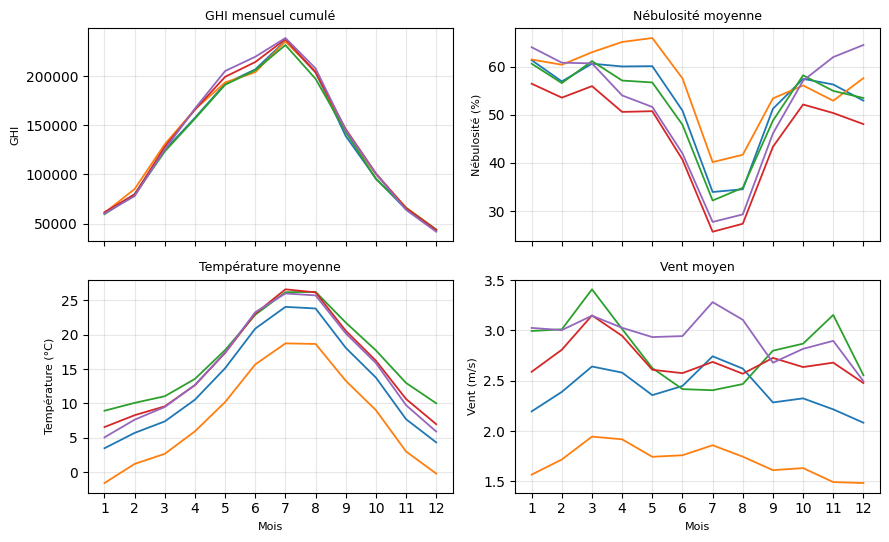

In [11]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(9, 6),   # très compact
    sharex=True
)

# =========================================================
# 1️⃣ GHI mensuel cumulé
# =========================================================
ax = axes[0, 0]

for ville in villes:
    ghi_monthly = (
        df[f"{ville}_ghi"]
        .resample("ME")
        .sum()
        .groupby(lambda x: x.month)
        .mean()
    )
    ax.plot(ghi_monthly.index, ghi_monthly.values, linewidth=1.3)

ax.set_title("GHI mensuel cumulé", fontsize=9)
ax.set_ylabel("GHI", fontsize=8)
ax.grid(True, alpha=0.3)


# =========================================================
# 2️⃣ Nébulosité moyenne mensuelle
# =========================================================
ax = axes[0, 1]

for ville in villes:
    cloud_monthly = (
        df[f"{ville}_nebulosite"]
        .resample("ME")
        .mean()
        .groupby(lambda x: x.month)
        .mean()
    )
    ax.plot(cloud_monthly.index, cloud_monthly.values, linewidth=1.3)

ax.set_title("Nébulosité moyenne", fontsize=9)
ax.set_ylabel("Nébulosité (%)", fontsize=8)
ax.grid(True, alpha=0.3)


# =========================================================
# 3️⃣ Température moyenne mensuelle
# =========================================================
ax = axes[1, 0]

for ville in villes:
    temp_monthly = (
        df[f"{ville}_temperature"]
        .resample("ME")
        .mean()
        .groupby(lambda x: x.month)
        .mean()
    )
    ax.plot(temp_monthly.index, temp_monthly.values, linewidth=1.3)

ax.set_title("Température moyenne", fontsize=9)
ax.set_ylabel("Température (°C)", fontsize=8)
ax.set_xlabel("Mois", fontsize=8)
ax.grid(True, alpha=0.3)


# =========================================================
# 4️⃣ Vent moyen mensuel
# =========================================================
ax = axes[1, 1]

for ville in villes:
    wind_monthly = (
        df[f"{ville}_vitesse_vent"]
        .resample("ME")
        .mean()
        .groupby(lambda x: x.month)
        .mean()
    )
    ax.plot(wind_monthly.index, wind_monthly.values, linewidth=1.3)

ax.set_title("Vent moyen", fontsize=9)
ax.set_ylabel("Vent (m/s)", fontsize=8)
ax.set_xlabel("Mois", fontsize=8)
ax.grid(True, alpha=0.3)


plt.xticks(range(1, 13))
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


# IV - Etude de correspondance entre variables communales

On a observé que les variables des différents points d'intérêt semblent avoir une distribution similaire. 

Comme ces données correspondent aux mêmes variables mesurées à quelques kilomètres de distance, on peut se demander si elles sont significativement ressemblantes entre elles, auquel cas il faudra les aggréger lors de la phase de feature engineering pour permettre aux modèles de performer efficacement.

## A - VIF

On peut, pour étudier la colinéarité, étudier le VIF (Variance Inflation Factor) : si les variables sont colinéaires, le VIF est élevé est supérieur à 5.

- 10 <= VIF : multicolinéarité significative
- 5 <= VIF < 10 : colinéarité importante (à investiguer)
- 1 <= VIF < 5 : pas de colinéarité

In [12]:
def check_vif(dataset, var_name, train_end='2023-12-31'):
    
    cols = []
    for ville in villes:
        cols.append(ville + '_' + var_name)
    
    df_sm = dataset[cols].copy()
    df_sm = df_sm[:train_end]
    
    scaler = StandardScaler()
    df_sm = scaler.fit_transform(df_sm)
    
    # Ajout de la constante pour l'intercept
    df_sm = sm.add_constant(df_sm)
    cols.insert(0, 'const')
    
    vif_data = pd.DataFrame()
    vif_data["Variable"] = cols
    vif_data["VIF"] = [variance_inflation_factor(df_sm, i) for i in range(df_sm.shape[1])]
    
    display(vif_data.iloc[1:].T)
    
    return vif_data['VIF'].mean()


In [13]:
# On calcule le VIF pour chaque type de variable appartenant aux 5 points d'intérêts
vif_tres_colineaires = []
vif_colineaires = []
vif_ok = []

for var in var_5pts:
    moy = check_vif(dataset=df, var_name=var)
    print("VIF moyen :", moy, '\n')
    
    # Tri des variables en fonction du VIF
    if moy > 10 :
        vif_tres_colineaires.append(var)
    elif moy > 5 :
        vif_colineaires.append(var)
    else :
        vif_ok.append(var)
        
print(f"""
Les {len(vif_tres_colineaires)} variables :
{vif_tres_colineaires} 
ont en moyenne un VIF supérieur à 10 et semblent particulièrement colinéaires 
entre les différents points d'intérêts concernés.

Les {len(vif_colineaires)} variables :
{vif_colineaires} 
ont en moyenne un VIF supérieur à 10 et semblent assez colinéaires entre les 
différents points d'intérêts concernés.

Les {len(vif_ok)} variables :
{vif_ok} 
ne semblent pas présenter de colinéarité entre les différents points d'intérêts 
concernés selon le critère du VIF.
""")


,1,2,3,4,5
Variable,cru_altitude,sel_altitude,svt_altitude,bra_altitude,eyg_altitude
VIF,2834026.149637,1048807.026475,511577.589844,1337710.042191,354401.523972


VIF moyen : 1014420.5553532558 



,1,2,3,4,5
Variable,cru_azimuth,sel_azimuth,svt_azimuth,bra_azimuth,eyg_azimuth
VIF,689.66365,355.502966,31.764013,930.040905,76.744856


VIF moyen : 347.45273162520994 



,1,2,3,4,5
Variable,cru_bhi,sel_bhi,svt_bhi,bra_bhi,eyg_bhi
VIF,10.098181,7.596941,5.636892,9.253886,7.124608


...

VIF moyen : 65.02993220291319 



,1,2,3,4,5
Variable,cru_toa,sel_toa,svt_toa,bra_toa,eyg_toa
VIF,93733204.972304,35508220.094266,5324453.962704,28069495.612859,1587870.639271


VIF moyen : 27370541.046900626 



,1,2,3,4,5
Variable,cru_vitesse_vent,sel_vitesse_vent,svt_vitesse_vent,bra_vitesse_vent,eyg_vitesse_vent
VIF,7.062242,3.040294,2.894589,5.318149,2.98141


VIF moyen : 3.716114202309148 


Les 11 variables :
['altitude', 'azimuth', 'clear_sky_bhi', 'clear_sky_bni', 'clear_sky_dhi', 'clear_sky_ghi', 'ghi', 'humidite', 'reliability', 'temperature', 'toa'] 
ont en moyenne un VIF supérieur à 10 et semblent particulièrement colinéaires 
entre les différents points d'intérêts concernés.

Les 2 variables :
['bhi', 'bni'] 
ont en moyenne un VIF supérieur à 10 et semblent assez colinéaires entre les 
différents points d'intérêts concernés.

Les 3 variables :
['dhi', 'nebulosite', 'vitesse_vent'] 
ne semblent pas présenter de colinéarité entre les différents points d'intérêts 
concernés selon le critère du VIF.



Les variables `dhi`, `nebulosite` et `vitesse_vent` dépendent des conditions géographiques bien différentes entre les différents points d'intérêt (conditions qui sont ont poussées à réaliser des mesures en cinq points différents) et ne semblent pas colinéaires selon le critère du VIF.

## B - Test de Durbin-Watson

On peut vérifier également les résultats du test de Durbin-Watson pour vérifier plus finement la ressemblance entre variables. Ce test permet de déterminer si les variables sont ou non autocorrélées.

Si le résultat de ce test :
- est compris entre 0 et 2 : il y a une autocorrélation positive
- est égale à 2 : il n'y a pas d'autocorrélation
- est compris entre 2 et 4 : il y a une autocorrélation négative


In [14]:
def check_durbin_watson(dataset, var_name, train_end='2023-12-31'):
    
    cols = []
    for ville in villes:
        cols.append(ville + '_' + var_name)
    
    df_sm = dataset[cols].copy()
    df_sm = df_sm[:train_end]
    
    scaler = StandardScaler()
    df_sm = scaler.fit_transform(df_sm)
    
    # Ajout de la constante pour l'intercept
    df_sm = sm.add_constant(df_sm)
    cols.insert(0, 'const')

    # Durbin-Watson test
    df_target = df['target'].copy()
    df_target = df_target[:train_end]
    model = sm.OLS(df_target, df_sm).fit()

    # Calculate Durbin-Watson statistic
    dw = durbin_watson(model.resid)
    
    return dw

In [15]:
# On réalise le test de Durbin-Watson pour chaque type de variable appartenant aux 5 points d'intérêts
dw_tres_colineaires = []
dw_colineaires = []
dw_ok = []

for var in var_5pts:
    dw = check_durbin_watson(dataset=df, var_name=var)
    print(f"Résultats de Durbin-Watson pour {var} : {dw:0.2f}")
        
    # Tri des variables en fonction du test de Durbin Watson
    if (3.5 < dw) or (dw < 0.5):
        dw_tres_colineaires.append(var)
    elif (3 < dw) or (dw < 1):
        dw_colineaires.append(var)
    else :
        dw_ok.append(var)
        
print(f"""
Les {len(dw_tres_colineaires)} variables :
{dw_tres_colineaires} 
ont un résultat au test de Durbin-Watson suggérant une forte autocorrélation 
entre les différents points d'intérêts concernés.

Les {len(dw_colineaires)} variable(s) :
{dw_colineaires} 
ont un résultat au test de Durbin-Watson suggérant une autocorrélation entre les 
différents points d'intérêts concernés.

Les {len(dw_ok)} variable(s) :
{dw_ok} 
ne semblent pas présenter d'autocorrélation entre les différents points d'intérêts 
concernés d'après le test de Durbin-Watson.
""")

Résultats de Durbin-Watson pour altitude : 0.37
Résultats de Durbin-Watson pour azimuth : 0.26
Résultats de Durbin-Watson pour bhi : 0.31
Résultats de Durbin-Watson pour bni : 0.38
Résultats de Durbin-Watson pour clear_sky_bhi : 0.31
Résultats de Durbin-Watson pour clear_sky_bni : 0.40
Résultats de Durbin-Watson pour clear_sky_dhi : 0.33
Résultats de Durbin-Watson pour clear_sky_ghi : 0.32
Résultats de Durbin-Watson pour dhi : 0.31
Résultats de Durbin-Watson pour ghi : 0.32
Résultats de Durbin-Watson pour humidite : 0.33
Résultats de Durbin-Watson pour nebulosite : 0.27
Résultats de Durbin-Watson pour reliability : 0.26
Résultats de Durbin-Watson pour temperature : 0.30
Résultats de Durbin-Watson pour toa : 0.32
Résultats de Durbin-Watson pour vitesse_vent : 0.28

Les 16 variables :
['altitude', 'azimuth', 'bhi', 'bni', 'clear_sky_bhi', 'clear_sky_bni', 'clear_sky_dhi', 'clear_sky_ghi', 'dhi', 'ghi', 'humidite', 'nebulosite', 'reliability', 'temperature', 'toa', 'vitesse_vent'] 
ont un

L'ensemble des groupe de variables que nous venons d'étudier semblent autocorrélée d'après le test de Durbin Watson.

La variable `toa` qui est la moins autocorrélée d'après ce test échoue au test du VIF.

En conclusion : toutes les variables concernant les données mesurées aux cinq points d'intérêts semblent corrélées entre elles : pour que notre futur modèle puisse obtenir des résultats robustes, il sera nécessaire d'aggréger ces données.


# IV - Aggrégation au niveau régional

Comme on vient de le voir, il semble nécessaire d'aggréger les données obtenues aux différents points d'intérêt entre elles.

Dans cette section, nous allons donc construire des variables régionales en combinant les mesures issues des stations locales, chacune associée à une commune représentative via un système de préfixes (`prefix`). 

Cette agrégation est réalisée au moyen d'une **somme pondérée**, où les poids sont définis à partir de la contribution énergétique de chaque commune, afin d'obtenir des indicateurs météorologiques régionaux cohérents avec la répartition spatiale de la production solaire.



In [16]:
def to_region(dataset): # Regroupement des colonnes
        """ Regroupe les variables concernant les communes """
        
        data = dataset.copy()
        poids = list(df_communes['poids'])
        
        # Mémoire des colonnes à supprimer
        cols_to_remove = []
        
        # Calcul de la somme pondérée
        for var in var_5pts: # Pour chacune des colonnes à rassembler
            col_name_region = f'region_{var}' # On crée le nom de la colonne "régionnale"
            data[col_name_region] = 0.0 # La somme pondérée est initialisée à 0

            # Récupération de tous les noms des colonnes à pondérer
            all_concerns_cols = [] # On contruit la liste des noms des colonnes communales concernées
            for ville in villes :
                all_concerns_cols.append(f"{ville}_{var}")
            
            # Calcul
            for p, col_ville in zip(poids, all_concerns_cols):
                data[col_name_region] = data[col_name_region] + p * data[col_ville]
                
            cols_to_remove.extend(all_concerns_cols)

        # Supression des colonnes devenues inutiles
        return data.drop(cols_to_remove, axis=1)


In [17]:
df = to_region(df)

# Tri des colonnes par ordre alphabétique
df = df.sort_index(axis=1)

display(df)
df.to_csv(output_path / 'temp_region_2020_2025.csv')


,consommation,region_altitude,region_azimuth,region_bhi,region_bni,region_clear_sky_bhi,region_clear_sky_bni,region_clear_sky_dhi,region_clear_sky_ghi,region_dhi,...,region_nebulosite,region_reliability,region_temperature,region_toa,region_vitesse_vent,signed_var_tch_tp30,solaire,target,tch_solaire,tco_solaire
datetime_utc,,,,,,,,,,,,,,,,,,,,,
2019-12-31 23:00:00+00:00,6123.0,-67.658747,334.860133,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,23.86520,1.0,3.23070,0.0,1.34110,0.0,0.0,0.0,0.0,0.0
2019-12-31 23:30:00+00:00,5907.0,-69.154695,353.234530,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,24.55650,1.0,3.38585,0.0,1.36150,0.0,0.0,0.0,0.0,0.0
2020-01-01 00:00:00+00:00,5724.0,-68.877374,12.560776,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,25.24780,1.0,3.54100,0.0,1.38190,0.0,0.0,0.0,0.0,0.0
2020-01-01 00:30:00+00:00,5749.0,-66.891776,30.183447,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,15.23310,1.0,3.60800,0.0,1.33655,0.0,0.0,0.0,0.0,0.0
2020-01-01 01:00:00+00:00,5700.0,-63.589084,44.705668,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,5.21840,1.0,3.67500,0.0,1.29120,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-30 21:30:00+00:00,5838.0,-56.223103,297.107647,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,36.40500,1.0,1.24320,0.0,3.31620,0.0,0.0,0.0,0.0,0.0
2025-12-30 22:00:00+00:00,5837.0,-60.811889,306.996098,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,37.02250,1.0,1.09590,0.0,3.27060,0.0,0.0,0.0,0.0,0.0
2025-12-30 22:30:00+00:00,6056.0,-64.763196,319.404019,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,36.08765,1.0,0.96695,0.0,3.15875,0.0,0.0,0.0,0.0,0.0


Les variables `region_` correspondent à une série météorologique synthétique représentant la région. Chaque station contribue proportionnellement à son poids
énergétique, ce qui garantit la cohérence entre la structure du parc photovoltaïque (et les communes représentatives) et la construction des indicateurs climatiques.